# Prepare Real and Synthetic Data

In [1]:
import pandas as pd
random_state= 2

## Read Real Data

## Read Synthetic Data

In [2]:

df_stays_synthetic = pd.read_csv("../../../data/synthetic/stays_synthetic.csv",sep='\t'  
                    ,parse_dates=['stayStartDate']
                       ,  dtype=
                 
                 { 'referralID':'int'
, 'stayID' : 'int'        

            


  
                     


                 }
  )
df_stays_synthetic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530007 entries, 0 to 530006
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   referralID     530007 non-null  int64         
 1   stayID         530007 non-null  int64         
 2   stayStartDate  530007 non-null  datetime64[ns]
 3   stayLength     530007 non-null  int64         
 4   personnelGrp   529816 non-null  object        
 5   stayTypeGrp    529487 non-null  object        
 6   specialist     526825 non-null  object        
 7   roleGrp        530001 non-null  object        
 8   cond1axis1Grp  529123 non-null  object        
 9   cond1axis2Grp  529705 non-null  object        
 10  cond1axis3Grp  530004 non-null  object        
 11  cond1axis4Grp  529753 non-null  object        
 12  cond1axis5Grp  529704 non-null  object        
 13  cond1axis6Grp  527306 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(10)
memory us

To validate the synthetising process, we  run a unsupervised model (clustering) on both the synthetic referal and real referal and compare the results. The clustering algithm used handles the mix of numerical and categorical feaztures in the dataset

In [3]:



df_referrals_synthetic = pd.read_csv("../../../data/synthetic/referrals_synthetic.csv",sep='\t'
                           ,parse_dates=['referralStartDate']
  ,dtype=
                 
                 {
   
 'referralID': 'int',
 'patientNr'  : 'int'                 
  
                 }
                                    
                                   )


df_referrals_synthetic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   referralID         46380 non-null  int64         
 1   referralStartDate  46380 non-null  datetime64[ns]
 2   referralLength     46380 non-null  int64         
 3   age                46380 non-null  int64         
 4   sex                46380 non-null  int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 1.8 MB


In [4]:
df_referrals_synthetic_eval = df_referrals_synthetic.copy()
df_stays_synthetic_eval = df_stays_synthetic.copy()
#df_patients_synthetic_eval = df_patients_synth.copy()

In [5]:
df_referrals_synthetic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   referralID         46380 non-null  int64         
 1   referralStartDate  46380 non-null  datetime64[ns]
 2   referralLength     46380 non-null  int64         
 3   age                46380 non-null  int64         
 4   sex                46380 non-null  int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 1.8 MB


In [6]:
df_stays_synthetic_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530007 entries, 0 to 530006
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   referralID     530007 non-null  int64         
 1   stayID         530007 non-null  int64         
 2   stayStartDate  530007 non-null  datetime64[ns]
 3   stayLength     530007 non-null  int64         
 4   personnelGrp   529816 non-null  object        
 5   stayTypeGrp    529487 non-null  object        
 6   specialist     526825 non-null  object        
 7   roleGrp        530001 non-null  object        
 8   cond1axis1Grp  529123 non-null  object        
 9   cond1axis2Grp  529705 non-null  object        
 10  cond1axis3Grp  530004 non-null  object        
 11  cond1axis4Grp  529753 non-null  object        
 12  cond1axis5Grp  529704 non-null  object        
 13  cond1axis6Grp  527306 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(10)
memory us

In [7]:
df_referrals_synthetic = df_referrals_synthetic.fillna(df_referrals_synthetic.mode().iloc[0])
df_referrals_synthetic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   referralID         46380 non-null  int64         
 1   referralStartDate  46380 non-null  datetime64[ns]
 2   referralLength     46380 non-null  int64         
 3   age                46380 non-null  int64         
 4   sex                46380 non-null  int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 1.8 MB


In [8]:
df_stays_synthetic_eval = df_stays_synthetic_eval.fillna(df_stays_synthetic_eval.mode().iloc[0])
df_stays_synthetic_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530007 entries, 0 to 530006
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   referralID     530007 non-null  int64         
 1   stayID         530007 non-null  int64         
 2   stayStartDate  530007 non-null  datetime64[ns]
 3   stayLength     530007 non-null  int64         
 4   personnelGrp   530007 non-null  object        
 5   stayTypeGrp    530007 non-null  object        
 6   specialist     530007 non-null  object        
 7   roleGrp        530007 non-null  object        
 8   cond1axis1Grp  530007 non-null  object        
 9   cond1axis2Grp  530007 non-null  object        
 10  cond1axis3Grp  530007 non-null  object        
 11  cond1axis4Grp  530007 non-null  object        
 12  cond1axis5Grp  530007 non-null  object        
 13  cond1axis6Grp  530007 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(10)
memory us

<Axes: xlabel='ageGrp'>

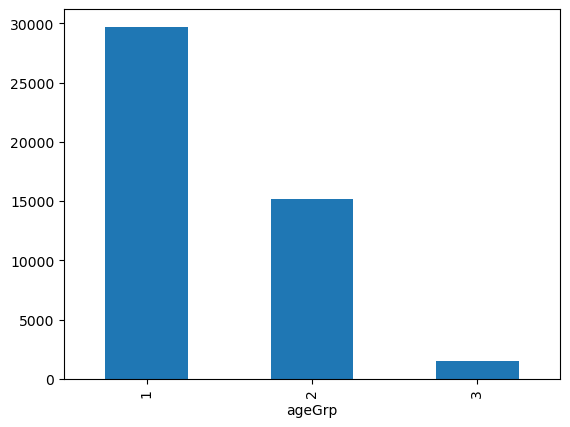

In [9]:
bins = [-1,13,20,10000 ]
labels = ['0-12','13-19', '20+']
df_referrals_synthetic_eval['ageGrpDesc'] = pd.cut(df_referrals_synthetic_eval.age, bins, labels = labels,include_lowest = True)
labels = ['1','2', '3']
df_referrals_synthetic_eval['ageGrp'] = pd.cut(df_referrals_synthetic_eval.age, bins, labels = labels,include_lowest = True)
df_referrals_synthetic_eval['ageGrp'].value_counts().plot(kind='bar')


In [10]:
df_referrals_synthetic_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   referralID         46380 non-null  int64         
 1   referralStartDate  46380 non-null  datetime64[ns]
 2   referralLength     46380 non-null  int64         
 3   age                46380 non-null  int64         
 4   sex                46380 non-null  int64         
 5   ageGrpDesc         46380 non-null  category      
 6   ageGrp             46380 non-null  category      
dtypes: category(2), datetime64[ns](1), int64(4)
memory usage: 1.9 MB


<Axes: xlabel='sexDesc'>

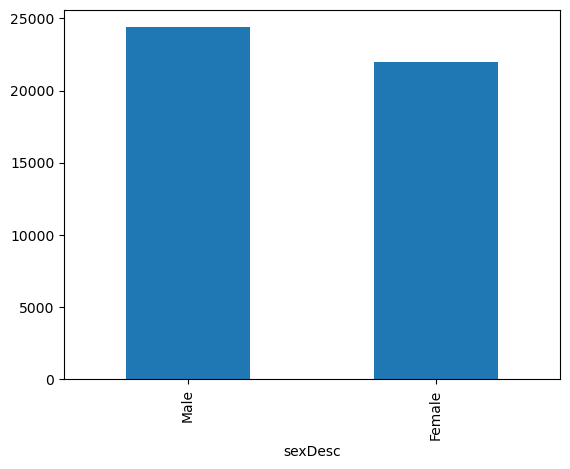

In [11]:
df_referrals_synthetic_eval['sexDesc'] = df_referrals_synthetic_eval['sex'].map({1:'Male', 2:'Female'})
df_referrals_synthetic_eval['sexDesc'].value_counts().plot(kind='bar')

In [12]:
df_referrals_synthetic_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   referralID         46380 non-null  int64         
 1   referralStartDate  46380 non-null  datetime64[ns]
 2   referralLength     46380 non-null  int64         
 3   age                46380 non-null  int64         
 4   sex                46380 non-null  int64         
 5   ageGrpDesc         46380 non-null  category      
 6   ageGrp             46380 non-null  category      
 7   sexDesc            46380 non-null  object        
dtypes: category(2), datetime64[ns](1), int64(4), object(1)
memory usage: 2.2+ MB


In [13]:

df =df_stays_synthetic_eval.groupby(['referralID']).agg({
#'kontaktTypeGrp_Direkte_pasientkontakt':'sum'
#,'kontaktTypeGrp_Indirekte_pasientkontakt':'sum'
'stayLength':'median' })
df.head()

,stayLength
referralID,
23190,104.0
23191,62.0
23192,91.5
23193,30.0
23194,43.5


In [14]:

              
                                         
                                         
                                        
df_referrals_synthetic_eval = pd.merge(df_referrals_synthetic_eval, df, how='left', left_on=['referralID'], right_on=['referralID'])
df_referrals_synthetic_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   referralID         46380 non-null  int64         
 1   referralStartDate  46380 non-null  datetime64[ns]
 2   referralLength     46380 non-null  int64         
 3   age                46380 non-null  int64         
 4   sex                46380 non-null  int64         
 5   ageGrpDesc         46380 non-null  category      
 6   ageGrp             46380 non-null  category      
 7   sexDesc            46380 non-null  object        
 8   stayLength         46380 non-null  float64       
dtypes: category(2), datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 2.6+ MB


In [15]:
sorted_df = df_stays_synthetic_eval[['referralID','stayStartDate','cond1axis1Grp']].sort_values(by=['referralID','stayStartDate'], ascending=True)
g= sorted_df.groupby(['referralID'])

In [16]:

df = g.head(1)[['referralID','cond1axis1Grp']]
df_referrals_synthetic_eval = pd.merge(df_referrals_synthetic_eval, df, how='left',on=['referralID'])
df_referrals_synthetic_eval.rename({'cond1axis1Grp': 'cond1axis1GrpFirst'}, axis=1, inplace=True) 
df_referrals_synthetic_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          46380 non-null  int64         
 1   referralStartDate   46380 non-null  datetime64[ns]
 2   referralLength      46380 non-null  int64         
 3   age                 46380 non-null  int64         
 4   sex                 46380 non-null  int64         
 5   ageGrpDesc          46380 non-null  category      
 6   ageGrp              46380 non-null  category      
 7   sexDesc             46380 non-null  object        
 8   stayLength          46380 non-null  float64       
 9   cond1axis1GrpFirst  46380 non-null  object        
dtypes: category(2), datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 2.9+ MB


In [17]:




## First
#sorted_df = df_stays_synthetic_eval[['referralID','stayStartDate','cond1axis1Grp']].sort_values(by=['referralID','stayStartDate'], ascending=True)
#g= sorted_df.groupby(['referralID'])

#df = g.head(1)[['referralID','cond1axis1Grp']]

#df_referals_synthetic_eval = pd.merge(df_referrals_synthetic_eval, df, how='left',on=['referralID'])
#df_referrals_synthetic_eval.info()
#df_referrals_synthetic_eval.rename(columns={'cond1axis1Grp':'cond1axis1GrpFirst'}, inplace=True)
#df_referals_synthetic_eval.head()
#df_referrals_synthetic_eval.info()
#df_referals_synthetic_eval.head()
### Last
df = g.tail(1)[['referralID','cond1axis1Grp']]
df_referrals_synthetic_eval = pd.merge(df_referrals_synthetic_eval, df, how='left',on=['referralID'])
df_referrals_synthetic_eval.rename(columns={'cond1axis1Grp': 'cond1axis1GrpLast'}, inplace=True)
df_referrals_synthetic_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          46380 non-null  int64         
 1   referralStartDate   46380 non-null  datetime64[ns]
 2   referralLength      46380 non-null  int64         
 3   age                 46380 non-null  int64         
 4   sex                 46380 non-null  int64         
 5   ageGrpDesc          46380 non-null  category      
 6   ageGrp              46380 non-null  category      
 7   sexDesc             46380 non-null  object        
 8   stayLength          46380 non-null  float64       
 9   cond1axis1GrpFirst  46380 non-null  object        
 10  cond1axis1GrpLast   46380 non-null  object        
dtypes: category(2), datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [18]:
stays_groupby= df_stays_synthetic_eval.groupby('referralID', as_index=False)['stayID'].count()
stays_groupby.head()


,referralID,stayID
0,23190,3
1,23191,14
2,23192,6
3,23193,16
4,23194,4


In [19]:
df_referrals_synthetic_eval = pd.merge(df_referrals_synthetic_eval, stays_groupby, how='left', left_on=['referralID'], right_on=['referralID'])
df_referrals_synthetic_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          46380 non-null  int64         
 1   referralStartDate   46380 non-null  datetime64[ns]
 2   referralLength      46380 non-null  int64         
 3   age                 46380 non-null  int64         
 4   sex                 46380 non-null  int64         
 5   ageGrpDesc          46380 non-null  category      
 6   ageGrp              46380 non-null  category      
 7   sexDesc             46380 non-null  object        
 8   stayLength          46380 non-null  float64       
 9   cond1axis1GrpFirst  46380 non-null  object        
 10  cond1axis1GrpLast   46380 non-null  object        
 11  stayID              46380 non-null  int64         
dtypes: category(2), datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 3.6+ MB


In [20]:
df_referrals_synthetic_eval.rename(columns = {'stayID':'numOfStays'}, inplace = True)

In [21]:
#df_referrals_synthetic_eval = pd.merge(df_referrals_synthetic_eval, df_patients_synthetic_eval,how='left', left_on=['patientNr'], right_on=['patientNr'] )
df_referrals_synthetic_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          46380 non-null  int64         
 1   referralStartDate   46380 non-null  datetime64[ns]
 2   referralLength      46380 non-null  int64         
 3   age                 46380 non-null  int64         
 4   sex                 46380 non-null  int64         
 5   ageGrpDesc          46380 non-null  category      
 6   ageGrp              46380 non-null  category      
 7   sexDesc             46380 non-null  object        
 8   stayLength          46380 non-null  float64       
 9   cond1axis1GrpFirst  46380 non-null  object        
 10  cond1axis1GrpLast   46380 non-null  object        
 11  numOfStays          46380 non-null  int64         
dtypes: category(2), datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 3.6+ MB


## Prepare  Data for validation (Cluster + Regression)

In [138]:
import functions
import importlib
importlib.reload(functions)



In [139]:
df_referrals_real_orig= df_referrals_t.copy()
df_referrals_synth_orig= df_referrals_synthetic_eval.copy()

In [140]:
df_referrals_real_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7730 entries, 0 to 7729
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          7730 non-null   int64         
 1   patientNr           7730 non-null   int64         
 2   age                 7730 non-null   int64         
 3   sex                 7730 non-null   object        
 4   referralStartDate   7730 non-null   datetime64[ns]
 5   referralEndDate     7730 non-null   datetime64[ns]
 6   referralLength      7730 non-null   int64         
 7   numOfStays          7730 non-null   int64         
 8   cond1axis1GrpLast   7730 non-null   object        
 9   cond1axis1GrpFirst  7730 non-null   object        
 10  sexDesc             7730 non-null   object        
 11  ageGrpDesc          7729 non-null   category      
 12  ageGrp              7729 non-null   category      
dtypes: category(2), datetime64[ns](2), int64(5), obj

In [141]:
df_referrals_synth_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46380 entries, 0 to 46379
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          46380 non-null  int64         
 1   referralStartDate   46380 non-null  datetime64[ns]
 2   referralLength      46380 non-null  int64         
 3   age                 46380 non-null  int64         
 4   sex                 46380 non-null  int64         
 5   ageGrpDesc          46380 non-null  category      
 6   ageGrp              46380 non-null  category      
 7   sexDesc             46380 non-null  object        
 8   stayLength          46380 non-null  float64       
 9   cond1axis1GrpFirst  46380 non-null  object        
 10  cond1axis1GrpLast   46380 non-null  object        
 11  numOfStays          46380 non-null  int64         
dtypes: category(2), datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 3.6+ MB


In [142]:
df_referrals_real_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7730 entries, 0 to 7729
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          7730 non-null   int64         
 1   patientNr           7730 non-null   int64         
 2   age                 7730 non-null   int64         
 3   sex                 7730 non-null   object        
 4   referralStartDate   7730 non-null   datetime64[ns]
 5   referralEndDate     7730 non-null   datetime64[ns]
 6   referralLength      7730 non-null   int64         
 7   numOfStays          7730 non-null   int64         
 8   cond1axis1GrpLast   7730 non-null   object        
 9   cond1axis1GrpFirst  7730 non-null   object        
 10  sexDesc             7730 non-null   object        
 11  ageGrpDesc          7729 non-null   category      
 12  ageGrp              7729 non-null   category      
dtypes: category(2), datetime64[ns](2), int64(5), obj

In [143]:
df_referrals_real_orig = df_referrals_real_orig[~df_referrals_real_orig.cond1axis1GrpLast.isin(['Z00-Z13','R40-R46','1999'])]

df_referrals_synth_orig = df_referrals_synth_orig[~df_referrals_synth_orig.cond1axis1GrpLast.isin(['Z00-Z13','R40-R46','1999'])]


In [144]:
df_referrals_real_orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4933 entries, 0 to 7727
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          4933 non-null   int64         
 1   patientNr           4933 non-null   int64         
 2   age                 4933 non-null   int64         
 3   sex                 4933 non-null   object        
 4   referralStartDate   4933 non-null   datetime64[ns]
 5   referralEndDate     4933 non-null   datetime64[ns]
 6   referralLength      4933 non-null   int64         
 7   numOfStays          4933 non-null   int64         
 8   cond1axis1GrpLast   4933 non-null   object        
 9   cond1axis1GrpFirst  4933 non-null   object        
 10  sexDesc             4933 non-null   object        
 11  ageGrpDesc          4932 non-null   category      
 12  ageGrp              4932 non-null   category      
dtypes: category(2), datetime64[ns](2), int64(5), object(4

In [145]:
df_referrals_synth_orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22656 entries, 0 to 46378
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          22656 non-null  int64         
 1   referralStartDate   22656 non-null  datetime64[ns]
 2   referralLength      22656 non-null  int64         
 3   age                 22656 non-null  int64         
 4   sex                 22656 non-null  int64         
 5   ageGrpDesc          22656 non-null  category      
 6   ageGrp              22656 non-null  category      
 7   sexDesc             22656 non-null  object        
 8   stayLength          22656 non-null  float64       
 9   cond1axis1GrpFirst  22656 non-null  object        
 10  cond1axis1GrpLast   22656 non-null  object        
 11  numOfStays          22656 non-null  int64         
dtypes: category(2), datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 1.9+ MB


remove referral-periods with 0 length and more than one episode

In [146]:
df_referrals_real_orig =df_referrals_real_orig[~((df_referrals_real_orig['referralLength']==0) &  (df_referrals_real_orig['numOfStays']>1)) ]
df_referrals_real_orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4929 entries, 0 to 7727
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          4929 non-null   int64         
 1   patientNr           4929 non-null   int64         
 2   age                 4929 non-null   int64         
 3   sex                 4929 non-null   object        
 4   referralStartDate   4929 non-null   datetime64[ns]
 5   referralEndDate     4929 non-null   datetime64[ns]
 6   referralLength      4929 non-null   int64         
 7   numOfStays          4929 non-null   int64         
 8   cond1axis1GrpLast   4929 non-null   object        
 9   cond1axis1GrpFirst  4929 non-null   object        
 10  sexDesc             4929 non-null   object        
 11  ageGrpDesc          4928 non-null   category      
 12  ageGrp              4928 non-null   category      
dtypes: category(2), datetime64[ns](2), int64(5), object(4

In [147]:
df_referrals_synth_orig =df_referrals_synth_orig[~((df_referrals_synth_orig['referralLength']==0) &  (df_referrals_synth_orig['numOfStays']>1)) ]
df_referrals_synth_orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22634 entries, 0 to 46378
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          22634 non-null  int64         
 1   referralStartDate   22634 non-null  datetime64[ns]
 2   referralLength      22634 non-null  int64         
 3   age                 22634 non-null  int64         
 4   sex                 22634 non-null  int64         
 5   ageGrpDesc          22634 non-null  category      
 6   ageGrp              22634 non-null  category      
 7   sexDesc             22634 non-null  object        
 8   stayLength          22634 non-null  float64       
 9   cond1axis1GrpFirst  22634 non-null  object        
 10  cond1axis1GrpLast   22634 non-null  object        
 11  numOfStays          22634 non-null  int64         
dtypes: category(2), datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 1.9+ MB


### Filter 20 + agegroup

In [148]:
df_referrals_real_orig = df_referrals_real_orig[~df_referrals_real_orig.ageGrpDesc.isin(['20+'])]
df_referrals_real_orig.info()

df_referrals_synth_orig = df_referrals_synth_orig[~df_referrals_synth_orig.ageGrpDesc.isin(['20+'])]
df_referrals_synth_orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4896 entries, 0 to 7727
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          4896 non-null   int64         
 1   patientNr           4896 non-null   int64         
 2   age                 4896 non-null   int64         
 3   sex                 4896 non-null   object        
 4   referralStartDate   4896 non-null   datetime64[ns]
 5   referralEndDate     4896 non-null   datetime64[ns]
 6   referralLength      4896 non-null   int64         
 7   numOfStays          4896 non-null   int64         
 8   cond1axis1GrpLast   4896 non-null   object        
 9   cond1axis1GrpFirst  4896 non-null   object        
 10  sexDesc             4896 non-null   object        
 11  ageGrpDesc          4895 non-null   category      
 12  ageGrp              4895 non-null   category      
dtypes: category(2), datetime64[ns](2), int64(5), object(4

### Recode Numerical Variables

In [149]:
import functions
import importlib
importlib.reload(functions)
from functions import get_knn_bins
from sklearn.preprocessing import KBinsDiscretizer

In [150]:
numeric_cols=['referralLength', 'numOfStays']

In [151]:
df_referrals_synth_orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21950 entries, 0 to 46378
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          21950 non-null  int64         
 1   referralStartDate   21950 non-null  datetime64[ns]
 2   referralLength      21950 non-null  int64         
 3   age                 21950 non-null  int64         
 4   sex                 21950 non-null  int64         
 5   ageGrpDesc          21950 non-null  category      
 6   ageGrp              21950 non-null  category      
 7   sexDesc             21950 non-null  object        
 8   stayLength          21950 non-null  float64       
 9   cond1axis1GrpFirst  21950 non-null  object        
 10  cond1axis1GrpLast   21950 non-null  object        
 11  numOfStays          21950 non-null  int64         
dtypes: category(2), datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 1.9+ MB


In [152]:
df_referrals_real_orig['factor'] =df_referrals_real_orig['referralLength']/365
df_referrals_real_orig['intensity']=df_referrals_real_orig['numOfStays']/df_referrals_real_orig['factor']

In [153]:
df_referrals_real_orig= df_referrals_real_orig.replace(np.inf, 0)

In [154]:
df_referrals_synth_orig['factor'] =df_referrals_synth_orig['referralLength']/365
df_referrals_synth_orig['intensity']=df_referrals_synth_orig['numOfStays']/df_referrals_synth_orig['factor']


In [155]:
df_referrals_synth_orig= df_referrals_synth_orig.replace(np.inf, 0)


In [156]:
bins = [0,15,51,30000]
labels = ['low' ,'medium','high']
df_referrals_synth_orig['intensityGrp'] = pd.cut(df_referrals_synth_orig.intensity, bins, labels = labels,include_lowest = True)

df_referrals_synth_orig['intensityGrp'].value_counts()

intensityGrp
low       15021
medium     5212
high       1717
Name: count, dtype: int64

In [157]:
bins = [0,15,51,30000]
labels = ['low' ,'medium','high']
df_referrals_real_orig['intensityGrp'] = pd.cut(df_referrals_real_orig.intensity, bins, labels = labels,include_lowest = True)
df_referrals_real_orig['intensityGrp'].value_counts()

intensityGrp
low       3617
medium    1176
high       103
Name: count, dtype: int64

In [158]:

df_referrals_synth_orig[df_referrals_synth_orig.isna().any(axis=1)]

,referralID,referralStartDate,referralLength,age,sex,ageGrpDesc,ageGrp,sexDesc,stayLength,cond1axis1GrpFirst,cond1axis1GrpLast,numOfStays,factor,intensity,intensityGrp


### remove a NAN

In [159]:

df_referrals_real_orig.dropna(inplace=True)

df_referrals_real_orig[df_referrals_real_orig.isna().any(axis=1)]
df_referrals_synth_orig.dropna(inplace=True)

df_referrals_synth_orig[df_referrals_synth_orig.isna().any(axis=1)]

,referralID,referralStartDate,referralLength,age,sex,ageGrpDesc,ageGrp,sexDesc,stayLength,cond1axis1GrpFirst,cond1axis1GrpLast,numOfStays,factor,intensity,intensityGrp


### Remove outliers

In [160]:
from pyod.models.ecod import ECOD
# https://github.com/yzhao062/pyod
numerical_features= ['referralLength','numOfStays']

df =df_referrals_synth_orig[ numerical_features]
clf = ECOD()
clf.fit(df)


out = clf.predict(df) 
df_referrals_synth_orig["outliers"] = out


df_referrals_synth_orig_no_out = df_referrals_synth_orig[df_referrals_synth_orig["outliers"] == 0]
df_referrals_synth_orig_no_out = df_referrals_synth_orig_no_out.drop(["outliers"], axis = 1)


df =df_referrals_real_orig[ numerical_features]
clf = ECOD()
clf.fit(df)


out = clf.predict(df) 
df_referrals_real_orig["outliers"] = out


df_referrals_real_orig_no_out = df_referrals_real_orig[df_referrals_real_orig["outliers"] == 0]
df_referrals_real_orig_no_out = df_referrals_real_orig_no_out.drop(["outliers"], axis = 1)

In [161]:

df_referrals_synth_orig.to_csv("../../../data/synthetic/referrals_synthetic_processed.csv", sep='\t',index=False)

In [162]:
df_referrals_real_orig.to_csv("../../../data/processed/referrals_real_processed.csv", sep='\t',index=False)